# Analiza avtomobilov

V tej projektni nalogi analiziram oglase za avtomobile, ki sem jih pridobil s spletne strani DoberAvto.si. Podatke sem s programom zajel iz več strani z oglasi, jih iz HTML-ja izluščil z uporabo knjižnice BeautifulSoup in regularnih izrazov ter jih nato shranil v datoteko CSV.

Za vsak avtomobil sem zbral naslednje podatke:

- ime avtomobila,
- znamko,
- letnik,
- število prevoženih kilometrov,
- vrsto goriva,
- tip menjalnika,
- moč motorja,
- ceno,
- vrsto prodajalca.

Nekateri oglasi nimajo vseh podatkov, zato se pri posameznih avtomobilih lahko pojavijo manjkajoče vrednosti. Pri analizi sem takšne primere izločil.

Glavni cilj analize je ugotoviti, katere lastnosti avtomobila so povezane z njegovo ceno ter kakšna je sestava ponudbe avtomobilov na spletni strani. Zato bom primerjal ceno z letnikom, kilometrino, znamko, močjo motorja, menjalnikom, gorivom in vrsto prodajalca. Poleg tega bom pogledal tudi, katere znamke in vrste goriva se med oglasi pojavljajo najpogosteje.

## Priprava podatkov

Pred analizo sem podatke najprej pripravil v primerno obliko. Uvozil sem knjižnici `pandas` in `matplotlib`, nato pa program prebere dokument `avti.csv`, ki jo je ustvaril za pridobivanje in urejanje podatkov.

Stolpci Letnik, Prevoženi kilometri, Moč motorja in Cena morajo biti številski, saj bom z njimi računal povprečja in risal grafe. Pri ceni in kilometrini uporabim `errors="coerce"`, zato se vrednosti, ki jih ni mogoče pretvoriti v število, spremenijo v manjkajoče vrednosti. Tako na primer zapis »Cena po dogovoru« ne povzroči napake pri računanju povprečne cene.

Na koncu sem izpisal prvih deset vrstic, da preverim, ali so bili podatki pravilno prebrani.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

avti = pd.read_csv("avti.csv")
pd.options.display.max_rows = 10

avti["Letnik"] = avti["Letnik"].astype("Int64")
avti["Prevoženi kilometri"] = pd.to_numeric(avti["Prevoženi kilometri"], errors="coerce").astype("Int64")
avti["Moč motorja"] = avti["Moč motorja"].astype("Int64")
avti["Cena"] = pd.to_numeric(avti["Cena"], errors="coerce").astype("Int64")

avti.head(10)

,Ime,Znamka,Letnik,Prevoženi kilometri,Tip goriva,Tip menjalnika,Moč motorja,Cena,Prodajalec
0,Mazda CX-30,Mazda,2026,7200,Bencin,Ročni,140,<NA>,Pravna oseba
1,KIA Stonic,KIA,2022,25741,Bencin,Ročni,84,<NA>,Pravna oseba
2,KIA Stonic,KIA,2023,47133,Bencin,Ročni,84,13499,Pravna oseba
3,BMW serija X2:,BMW,2020,138000,Bencin,Avtomatski,136,17675,Pravna oseba
4,BMW serija 1:,BMW,2022,115000,Dizel,Ročni,116,15989,Pravna oseba
5,BMW X1,BMW,2019,189000,Dizel,Ročni,116,11500,Pravna oseba
6,BMW serija X2:,BMW,2018,161000,Dizel,Ročni,150,16788,Pravna oseba
7,Peugeot 2008,Peugeot,2019,116830,Bencin,Ročni,131,<NA>,Pravna oseba
8,Opel Corsa,Opel,2023,39000,Bencin,Ročni,101,10999,Pravna oseba
9,Volkswagen Polo,Volkswagen,2018,102300,Bencin,Ročni,116,9490,Pravna oseba


## Povprečna cena glede na letnik

Najprej bom preveril povezavo med letnikom avtomobila in njegovo ceno. Smiselno je pričakovati, da bodo novejši avtomobili v povprečju dražji, saj so običajno manj obrabljeni in imajo novejšo opremo.

Avtomobile združim glede na letnik in za vsak letnik izračunam povprečno ceno. Rezultate uredim po letnikih in jih prikažem s črtnim grafom, saj tako lažje opazujem spreminjanje cene skozi čas.

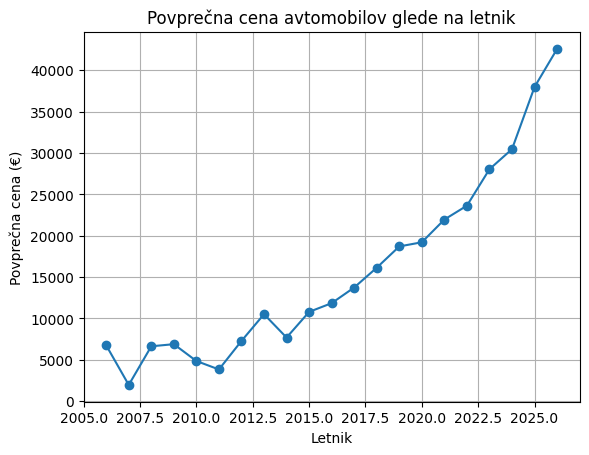

In [16]:
povprecna_cena = avti.groupby("Letnik")["Cena"].mean().sort_index()

povprecna_cena.plot(kind="line", marker="o")
plt.title("Povprečna cena avtomobilov glede na letnik")
plt.xlabel("Letnik")
plt.ylabel("Povprečna cena (€)")
plt.grid()
plt.show()

Iz grafa lahko opazujemo, kako se povprečna cena spreminja glede na letnik avtomobila. Splošno lahko pričakujemo višje cene pri novejših vozilih, vendar posamezni letniki lahko od tega trenda odstopajo.

Pri razlagi moramo upoštevati, da za vse letnike nimamo enakega števila avtomobilov. Če je za določen letnik v podatkih samo nekaj oglasov, lahko že en zelo drag ali zelo poceni avtomobil precej spremeni povprečje.

## Cena glede na prevožene kilometre

Naslednja lastnost, ki jo bom primerjal s ceno, je število prevoženih kilometrov. Več prevoženih kilometrov navadno pomeni večjo obrabo avtomobila, zato pričakujem, da bodo avtomobili z višjo kilometrino pogosto cenejši.

Tokrat ne računam povprečja po posameznih kilometrih, saj ima skoraj vsak avtomobil drugačno kilometrino. Namesto tega uporabim točkovni graf, kjer vsaka točka predstavlja en avtomobil. Tako lahko neposredno opazujem povezavo med kilometrino in ceno.

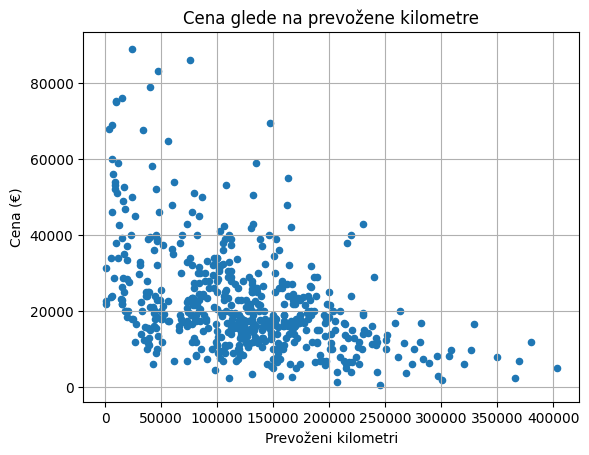

In [17]:
avti.dropna(subset=["Cena", "Prevoženi kilometri"]).plot(kind="scatter", x="Prevoženi kilometri", y="Cena")
plt.title("Cena glede na prevožene kilometre")
plt.xlabel("Prevoženi kilometri")
plt.ylabel("Cena (€)")
plt.grid()
plt.show()

Na grafu lahko preverimo, ali se z večanjem kilometrine cena avtomobila praviloma zmanjšuje. Točke niso razporejene popolnoma enakomerno, saj na ceno ne vpliva samo kilometrina.

Na vrednost avtomobila vplivajo tudi letnik, znamka, model, moč motorja, vrsta goriva in druge lastnosti. Zato lahko tudi avtomobil z veliko kilometri ostane razmeroma drag, če gre na primer za novejši ali dražji model.

## Povprečna cena glede na znamko

Poleg starosti in kilometrine me zanima tudi, kako se cene razlikujejo med avtomobilskimi znamkami. Nekatere znamke imajo v ponudbi več dražjih ali zmogljivejših modelov, druge pa več cenovno dostopnih avtomobilov.

Za vsako znamko izračunam povprečno ceno vseh avtomobilov te znamke. Rezultate uredim od najnižje do najvišje povprečne cene in jih prikažem z vodoravnim stolpčnim grafom, ker je pri večjem številu znamk tako zapis bolj pregleden.

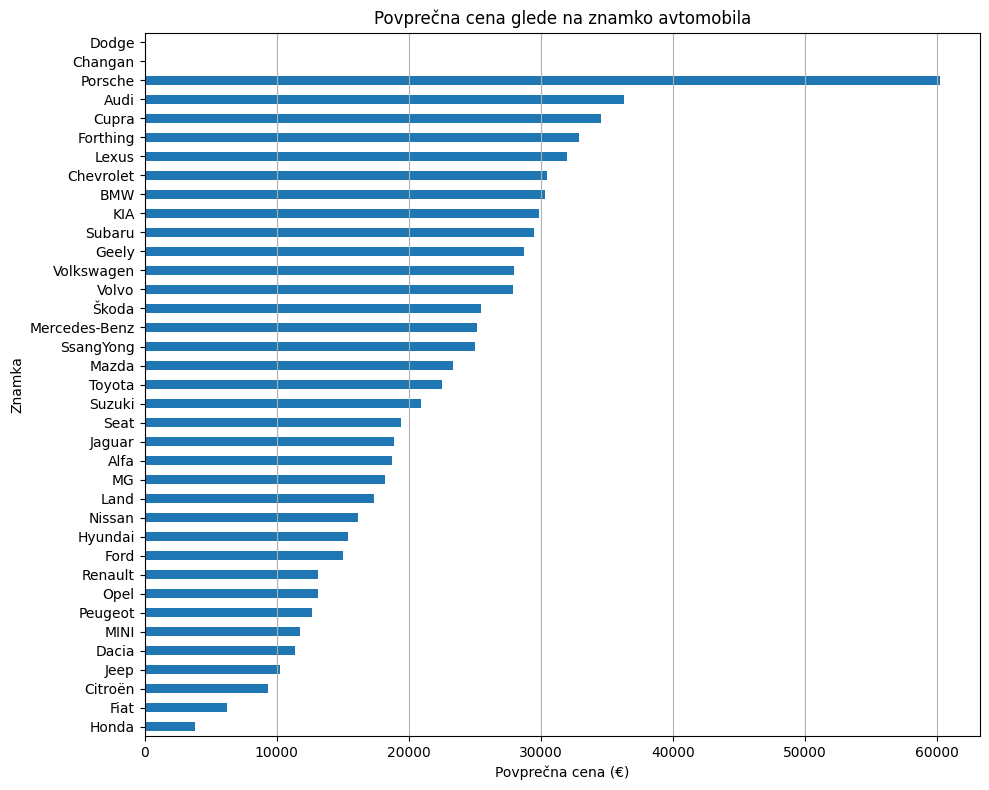

In [18]:
povprecna_cena_znamka = avti.groupby("Znamka")["Cena"].mean().sort_values()

povprecna_cena_znamka.plot(kind="barh", figsize=(10, 8))
plt.title("Povprečna cena glede na znamko avtomobila")
plt.xlabel("Povprečna cena (€)")
plt.ylabel("Znamka")
plt.grid(axis="x")
plt.tight_layout()
plt.show()

Graf pokaže, da se povprečne cene med znamkami lahko precej razlikujejo. Pri primerjavi pa moramo biti previdni, saj znamke v podatkih niso zastopane z enakim številom oglasov.

Če ima določena znamka samo enega ali dva avtomobila, njena povprečna cena ni nujno dober prikaz običajne cene te znamke. Zato naslednja analiza pokaže tudi, katere znamke se v podatkih pojavljajo najpogosteje.

## Najpogostejše znamke avtomobilov

Po primerjavi povprečnih cen me zanima še, katere znamke se med oglasi sploh najpogosteje pojavljajo. To nam pove nekaj o sestavi ponudbe na spletni strani in pomaga pri razlagi prejšnjega grafa.

Najprej preštejem število avtomobilov posamezne znamke in izračunam njihov delež med vsemi oglasi. Ker je različnih znamk veliko, zaradi preglednosti na tortnem grafu prikažem samo znamke, ki predstavljajo več kot 3 % vseh zajetih oglasov.

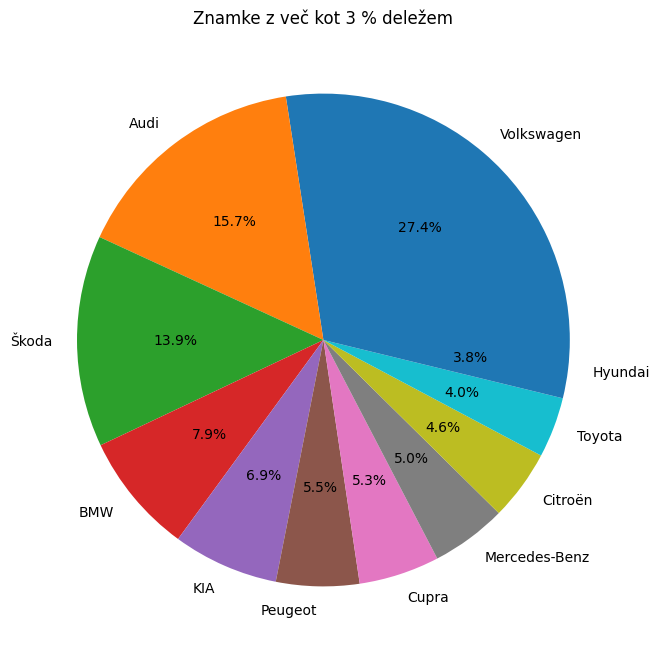

In [19]:
stevilo_znamk = avti["Znamka"].value_counts()
delezi = stevilo_znamk / stevilo_znamk.sum() * 100
znamke_nad_3 = stevilo_znamk[delezi > 3]

znamke_nad_3.plot(kind="pie", autopct="%1.1f%%", figsize=(8, 8))
plt.title("Znamke z več kot 3 % deležem")
plt.ylabel("")
plt.show()

Iz grafa lahko hitro vidimo, katere znamke predstavljajo največji del zajetih oglasov. Znamke z manjšim deležem niso prikazane, saj bi bil tortni graf ob prevelikem številu majhnih kosov težko berljiv.

Ta podatek je pomemben tudi pri drugih analizah. Rezultat za znamko, ki ima veliko oglasov, je praviloma bolj reprezentativen kot rezultat znamke, pri kateri imamo samo nekaj avtomobilov.

## Vrsta goriva

Avtomobili se razlikujejo tudi glede na vrsto goriva oziroma pogona. V podatkih se lahko pojavijo bencinski, dizelski, električni, hibridni in drugi avtomobili.

Zanima me, katere vrste goriva so med zajetimi oglasi najbolj pogoste. Zato preštejem avtomobile posamezne vrste goriva in njihove deleže prikažem s tortnim grafom.

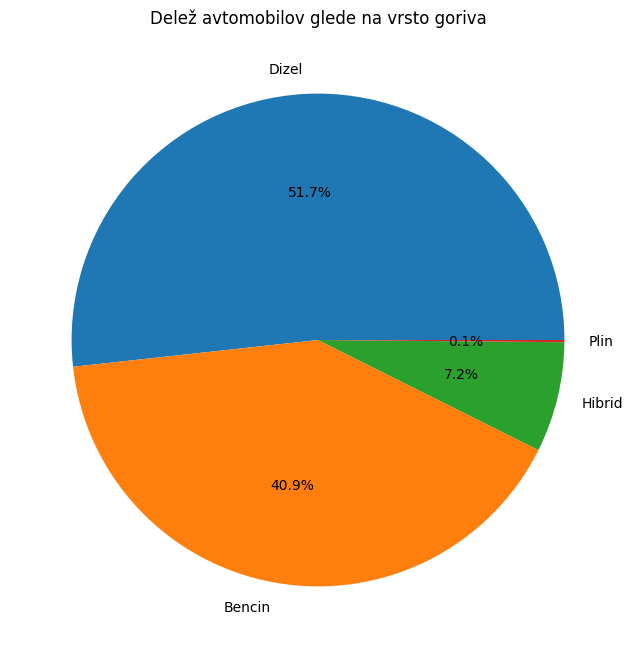

In [20]:
vrste_goriva = avti["Tip goriva"].value_counts()

vrste_goriva.plot(kind="pie", autopct="%1.1f%%", figsize=(8, 8))
plt.title("Delež avtomobilov glede na vrsto goriva")
plt.ylabel("")
plt.show()

Tortni graf prikazuje, kako je ponudba avtomobilov razdeljena glede na vrsto goriva. Tako lahko hitro vidimo, kateri tip pogona se pojavlja najpogosteje in kateri redkeje.

Pri tem je treba upoštevati, da nekateri oglasi nimajo pravilno prepoznane vrste goriva. Ti manjkajoči podatki se pri `value_counts()` ne štejejo med prikazane kategorije.

## Vrsta prodajalca

Naslednja analiza se ne nanaša na lastnosti avtomobila, ampak na prodajalca. Oglas lahko objavi fizična oseba ali pravna oseba, na primer avtohiša oziroma podjetje.

Zanima me, katera vrsta prodajalca predstavlja večji delež ponudbe. Število oglasov obeh skupin preštejem in rezultat prikažem s tortnim grafom.

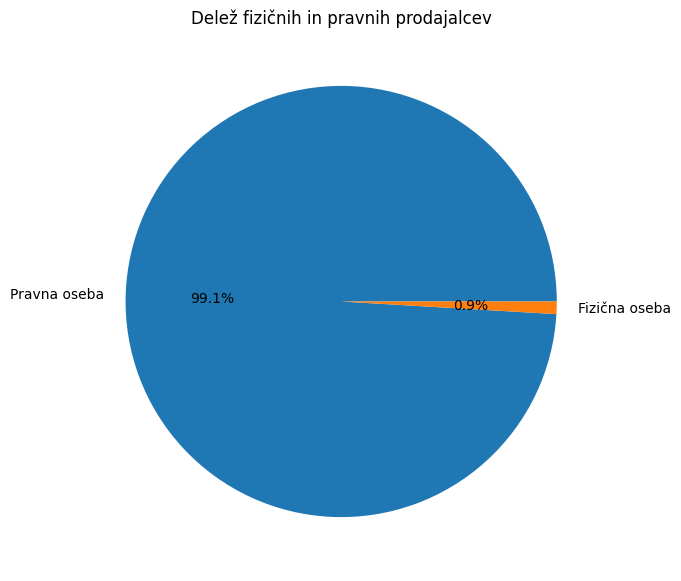

In [21]:
vrste_prodajalcev = avti["Prodajalec"].value_counts()

vrste_prodajalcev.plot(kind="pie", autopct="%1.1f%%", figsize=(7, 7))
plt.title("Delež fizičnih in pravnih prodajalcev")
plt.ylabel("")
plt.show()

Graf pokaže razmerje med oglasi fizičnih in pravnih oseb. Tako lahko ocenimo, ali na spletni strani večino ponudbe predstavljajo zasebni prodajalci ali podjetja.

Ta primerjava je zanimiva tudi zato, ker bom kasneje preveril, ali se med tema skupinama razlikuje tudi povprečna cena avtomobilov.

## Cena glede na moč motorja

Poleg letnika in kilometrine lahko na ceno vpliva tudi moč motorja. Močnejši avtomobili so pogosto večji, dražji ali bolj športno usmerjeni, zato me zanima, ali se z večjo močjo povečuje tudi cena.

Vsak avtomobil ponovno predstavim kot eno točko. Na vodoravni osi je moč motorja v konjskih močeh, na navpični osi pa cena avtomobila.

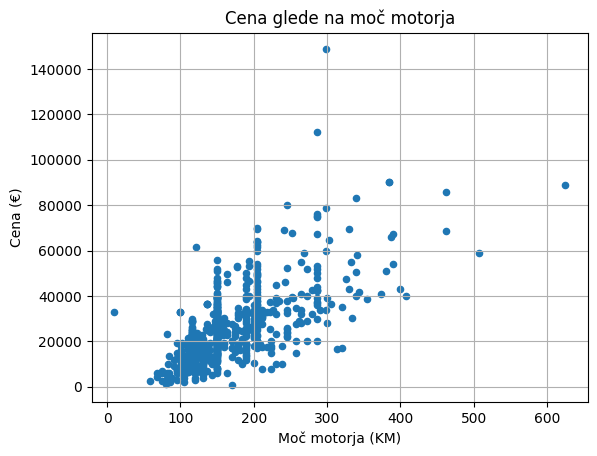

In [22]:
avti.dropna(subset=["Cena", "Moč motorja"]).plot(kind="scatter", x="Moč motorja", y="Cena")
plt.title("Cena glede na moč motorja")
plt.xlabel("Moč motorja (KM)")
plt.ylabel("Cena (€)")
plt.grid()
plt.show()

Na grafu lahko opazujemo, ali se pri večji moči motorja pojavljajo tudi višje cene. Pri nekaterih avtomobilih bodo verjetno prisotna večja odstopanja.

Samo iz moči motorja namreč ne moremo natančno določiti cene. Pomembni so tudi starost, znamka, model, oprema in kilometrina, zato je ta graf predvsem prikaz splošne povezave med dvema spremenljivkama.

## Povprečna cena glede na tip menjalnika

Sedaj bom avtomobile razdelil še glede na tip menjalnika. V podatkih se pojavljata predvsem ročni in avtomatski menjalnik.

Za obe skupini izračunam povprečno ceno. S tem lahko preverim, ali so avtomobili z avtomatskim menjalnikom v zajetih oglasih v povprečju dražji ali cenejši od avtomobilov z ročnim menjalnikom.

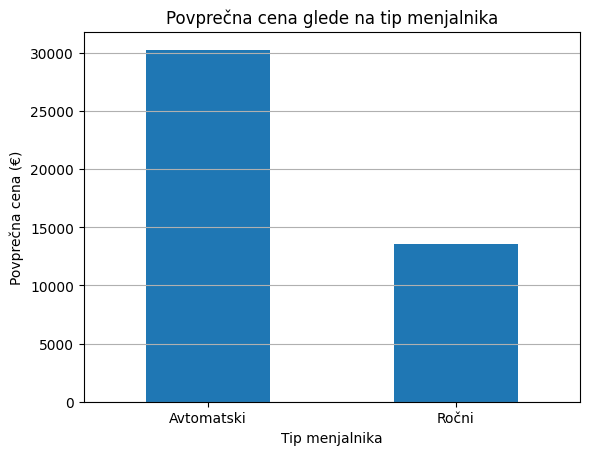

In [23]:
cena_menjalnik = avti.groupby("Tip menjalnika")["Cena"].mean()

cena_menjalnik.plot(kind="bar")
plt.title("Povprečna cena glede na tip menjalnika")
plt.xlabel("Tip menjalnika")
plt.ylabel("Povprečna cena (€)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

Stolpca omogočata neposredno primerjavo povprečne cene obeh vrst menjalnika. Razlika pa še ne pomeni nujno, da menjalnik sam povzroča višjo ceno.

Avtomatski menjalniki so lahko na primer pogostejši pri novejših, močnejših ali dražjih avtomobilih. Zato rezultat opisuje predvsem razliko med skupinama v mojih podatkih.

## Povprečna cena glede na vrsto goriva

Ker sem prej že pogledal, katere vrste goriva se najpogosteje pojavljajo, bom zdaj preveril še njihove povprečne cene.

Avtomobile združim glede na vrsto goriva in za vsako skupino izračunam povprečno ceno. Tako lahko na enem grafu primerjam na primer bencinske, dizelske, električne in hibridne avtomobile.

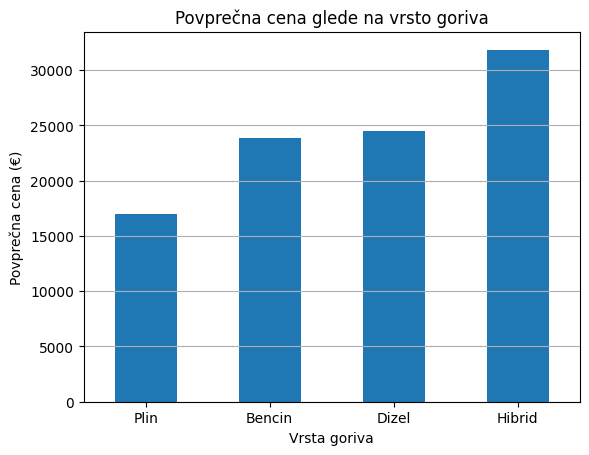

In [24]:
povprecna_cena_gorivo = avti.groupby("Tip goriva")["Cena"].mean().sort_values()

povprecna_cena_gorivo.plot(kind="bar")
plt.title("Povprečna cena glede na vrsto goriva")
plt.xlabel("Vrsta goriva")
plt.ylabel("Povprečna cena (€)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

Ta primerjava pokaže, ali se med posameznimi vrstami goriva pojavljajo večje razlike v povprečni ceni. Razlike so lahko povezane tudi z letnikom avtomobilov, saj so na primer električni in hibridni avtomobili pogosto novejši.

Zato rezultata ne smemo razlagati samo kot vpliv vrste goriva, ampak kot primerjavo avtomobilov, ki se trenutno pojavljajo v zajetih oglasih.

## Povprečna cena glede na vrsto prodajalca

Prej sem primerjal, koliko oglasov objavljajo fizične in pravne osebe. Zdaj me zanima še, ali se med tema skupinama razlikuje povprečna cena avtomobilov.

Avtomobile razdelim glede na vrsto prodajalca in za vsako skupino izračunam povprečno ceno. Tako lahko preverim, ali podjetja in zasebni prodajalci ponujajo cenovno podobne avtomobile.

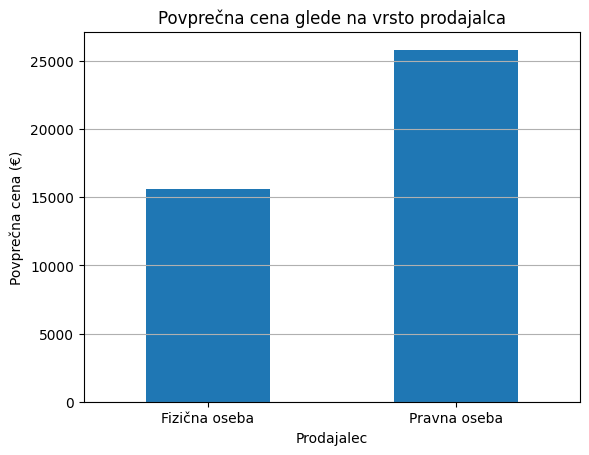

In [25]:
povprecna_cena_prodajalec = avti.groupby("Prodajalec")["Cena"].mean()

povprecna_cena_prodajalec.plot(kind="bar")
plt.title("Povprečna cena glede na vrsto prodajalca")
plt.xlabel("Prodajalec")
plt.ylabel("Povprečna cena (€)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


Graf pokaže razliko med povprečno ceno avtomobilov fizičnih in pravnih oseb. Morebitna razlika je lahko posledica tega, da imajo pravne osebe drugačno ponudbo vozil, na primer več novejših avtomobilov.

Zato tudi tukaj rezultat razumem kot primerjavo dveh skupin v mojih podatkih in ne kot dokaz, da vrsta prodajalca sama določa ceno.

## Povprečno število kilometrov glede na vrsto goriva

Za zadnjo primerjavo me zanima, ali imajo avtomobili z različnimi vrstami goriva tudi različno povprečno kilometrino. To lahko pove nekaj o starosti in načinu uporabe različnih skupin vozil.

Avtomobile združim glede na vrsto goriva in za vsako skupino izračunam povprečno število prevoženih kilometrov. Rezultate nato primerjam s stolpčnim grafom.

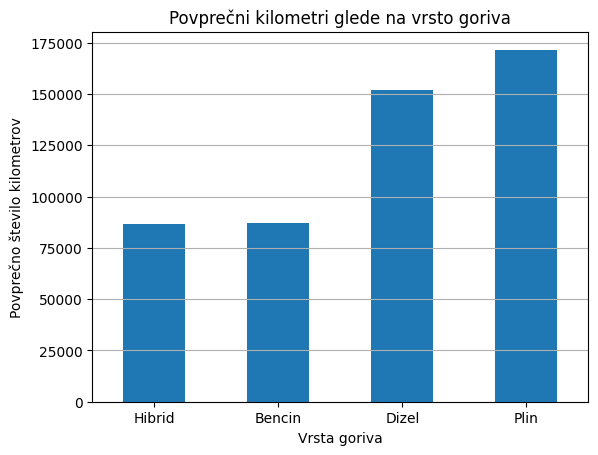

In [26]:
povprecni_kilometri = avti.groupby("Tip goriva")["Prevoženi kilometri"].mean().sort_values()

povprecni_kilometri.plot(kind="bar")
plt.title("Povprečni kilometri glede na vrsto goriva")
plt.xlabel("Vrsta goriva")
plt.ylabel("Povprečno število kilometrov")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()


Ta graf omogoča primerjavo povprečne kilometrine med različnimi vrstami goriva. Če ima določena skupina precej nižjo povprečno kilometrino, je lahko eden od razlogov tudi ta, da so ti avtomobili v povprečju novejši.

Rezultat zato dopolnjuje prejšnje analize in pokaže, da so posamezne lastnosti avtomobilov med seboj povezane ter jih ni vedno smiselno obravnavati popolnoma ločeno.

## Zaključek

V projektni nalogi sem analiziral oglase za avtomobile s spletne strani DoberAvto.si. Podatke sem najprej samodejno pridobil s spleta, jih iz HTML-ja uredil in shranil v datoteko CSV, nato pa sem jih analiziral v Jupyter Notebooku.

Pri analizi sem preveril povezavo med ceno in letnikom, prevoženimi kilometri, znamko, močjo motorja, tipom menjalnika ter vrsto goriva. Poleg tega sem pogledal, katere znamke in vrste goriva se najpogosteje pojavljajo, kakšno je razmerje med fizičnimi in pravnimi prodajalci, kako se njihova povprečna cena razlikuje ter kakšna je povprečna kilometrina pri različnih vrstah goriva.

Iz analiz je razvidno, da cene avtomobila ne moremo pojasniti samo z eno lastnostjo. Letnik, kilometrina, moč motorja, znamka in druge lastnosti so med seboj povezane in skupaj vplivajo na ponudbo ter ceno avtomobila.

Pri interpretaciji rezultatov je pomembno tudi število oglasov v posamezni skupini in prisotnost manjkajočih podatkov. Zato so grafi predvsem opis zajetih oglasov v času pridobivanja podatkov, ne pa popoln opis celotnega slovenskega trga avtomobilov.